# Deep Learning, DL Models and Applications
## Skill Development Tasks (1-15)

### Implementations:
- Neural Networks from Scratch
- Optimization Algorithms
- CNN Architectures
- Sequence Models
- Generative Models
- Transformers
- Distributed Training

### Frameworks:
- NumPy
- PyTorch
- TorchVision
- Matplotlib
- SciPy
- Scikit-Learn

Nandana R Nair

In [77]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [78]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Task 4: Custom Gradient Descent Optimizers

## Objective

Implement three popular optimization algorithms from scratch using only PyTorch tensor operations.

### Optimizers
- Momentum Gradient Descent
- RMSProp
- Adam

### Restrictions
- No torch.optim
- No built-in optimizer classes

The optimizers will be compared by observing their convergence on a simple regression problem.

In [79]:
#Import Libraries
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [80]:
#Create Synthetic Dataset
x = torch.linspace(-5,5,200).reshape(-1,1)

noise = torch.randn_like(x)*0.5

y = 3*x + 2 + noise

In [81]:
#Initialize Parameters
def initialize_parameters():

    w = torch.randn(1, requires_grad=False)

    b = torch.randn(1, requires_grad=False)

    return w,b

In [82]:
#Forward Pass
def forward(x,w,b):

    return w*x + b

In [83]:
#Mean Squared Error Loss
def mse_loss(prediction,target):

    return torch.mean((prediction-target)**2)

In [84]:
#Compute Gradients Manually
def compute_gradients(x,y,w,b):

    prediction = forward(x,w,b)

    error = prediction-y

    dw = (2/len(x))*torch.sum(error*x)

    db = (2/len(x))*torch.sum(error)

    loss = mse_loss(prediction,y)

    return dw,db,loss

In [85]:
#Momentum Optimizer
def train_momentum(lr=0.01,momentum=0.9,epochs=100):

    w,b = initialize_parameters()

    vw = torch.zeros_like(w)

    vb = torch.zeros_like(b)

    losses=[]

    for epoch in range(epochs):

        dw,db,loss = compute_gradients(x,y,w,b)

        vw = momentum*vw - lr*dw

        vb = momentum*vb - lr*db

        w += vw

        b += vb

        losses.append(loss.item())

    return losses

In [86]:
#RMSProp Optimizer
def train_rmsprop(lr=0.01,beta=0.9,eps=1e-8,epochs=100):

    w,b = initialize_parameters()

    sw = torch.zeros_like(w)

    sb = torch.zeros_like(b)

    losses=[]

    for epoch in range(epochs):

        dw,db,loss = compute_gradients(x,y,w,b)

        sw = beta*sw + (1-beta)*(dw**2)

        sb = beta*sb + (1-beta)*(db**2)

        w -= lr*dw/(torch.sqrt(sw)+eps)

        b -= lr*db/(torch.sqrt(sb)+eps)

        losses.append(loss.item())

    return losses

In [87]:
#Adam Optimizer
def train_adam(
    lr=0.01,
    beta1=0.9,
    beta2=0.999,
    eps=1e-8,
    epochs=100
):

    w,b = initialize_parameters()

    mw = torch.zeros_like(w)
    vw = torch.zeros_like(w)

    mb = torch.zeros_like(b)
    vb = torch.zeros_like(b)

    losses=[]

    for t in range(1,epochs+1):

        dw,db,loss = compute_gradients(x,y,w,b)

        mw = beta1*mw + (1-beta1)*dw
        mb = beta1*mb + (1-beta1)*db

        vw = beta2*vw + (1-beta2)*(dw**2)
        vb = beta2*vb + (1-beta2)*(db**2)

        mw_hat = mw/(1-beta1**t)
        mb_hat = mb/(1-beta1**t)

        vw_hat = vw/(1-beta2**t)
        vb_hat = vb/(1-beta2**t)

        w -= lr*mw_hat/(torch.sqrt(vw_hat)+eps)
        b -= lr*mb_hat/(torch.sqrt(vb_hat)+eps)

        losses.append(loss.item())

    return losses

In [88]:
#Train All Optimizers
momentum_loss = train_momentum()

rmsprop_loss = train_rmsprop()

adam_loss = train_adam()

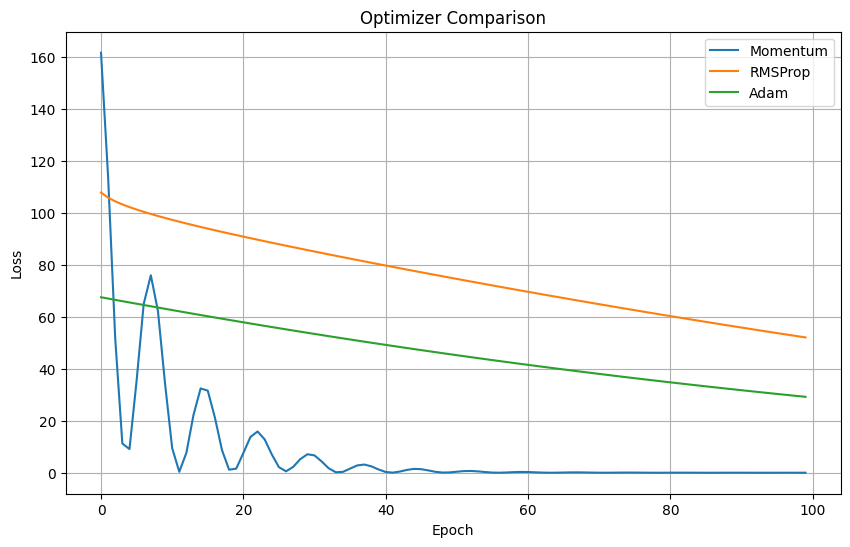

In [89]:
#Plot Convergence
plt.figure(figsize=(10,6))

plt.plot(momentum_loss,label="Momentum")

plt.plot(rmsprop_loss,label="RMSProp")

plt.plot(adam_loss,label="Adam")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Optimizer Comparison")

plt.grid(True)

plt.legend()

plt.show()

In [90]:
#Final Comparison
print("="*50)

print("Final Losses")

print("="*50)

print(f"Momentum : {momentum_loss[-1]:.4f}")

print(f"RMSProp  : {rmsprop_loss[-1]:.4f}")

print(f"Adam     : {adam_loss[-1]:.4f}")

Final Losses
Momentum : 0.2413
RMSProp  : 52.1795
Adam     : 29.3794


In [91]:
#Summary
print("""
Task 4 Completed Successfully!

Implemented from scratch:
✔ Momentum Gradient Descent
✔ RMSProp
✔ Adam Optimizer

No torch.optim was used.

The convergence curves demonstrate the different learning behaviors of each optimizer on the same regression task.
""")


Task 4 Completed Successfully!

Implemented from scratch:
✔ Momentum Gradient Descent
✔ RMSProp
✔ Adam Optimizer

No torch.optim was used.

The convergence curves demonstrate the different learning behaviors of each optimizer on the same regression task.

